# Tugas Pemograman Paralel
**NIM:** 2411512025
**Nama:** Equilibrilio Adilia
**Mata Kuliah:** Pemograman Paralel



In [1]:
## Tugas Perhitungan BMI
tb = float(input('masukkan tinggi badan'))
bb = float(input('masukkan berat badan'))

bbtb = bb/((tb*tb)/10000)

if bbtb < 18.5:
    print('kurang berat badan')
elif 18.5 < bbtb < 22.9:
    print('normal')
elif 23 < bbtb < 24.9:
    print('kelebihan berat badan')
elif 25 < bbtb < 29.9:
    print('obesitas tingkat 1')
elif bbtb > 30:
    print('obesitasi tingkat 2')


normal


## 1. Klasifikasi Flynn

Taksonomi Flynn mengklasifikasikan arsitektur komputer berdasarkan jumlah **aliran instruksi (Instruction Stream)** dan **aliran data (Data Stream)** yang dapat diproses secara bersamaan: SISD, SIMD, MISD, MIMD.

In [2]:
# Tidak ada kode eksekusi untuk bagian ini — analisis konseptual.
# Ringkasan definisi untuk referensi:
definisi_flynn = {
    "SISD": "Single Instruction, Single Data — satu instruksi memproses satu data pada satu waktu (eksekusi sekuensial klasik).",
    "SIMD": "Single Instruction, Multiple Data — satu instruksi yang sama diterapkan serentak ke banyak elemen data (vectorization).",
    "MISD": "Multiple Instruction, Single Data — beberapa instruksi berbeda memproses data yang sama secara bersamaan (jarang dipakai, mis. sistem fault-tolerant).",
    "MIMD": "Multiple Instruction, Multiple Data — beberapa unit pemroses menjalankan instruksi berbeda pada data berbeda secara independen (cluster, multicore modern)."
}
for k, v in definisi_flynn.items():
    print(f"{k}: {v}")

SISD: Single Instruction, Single Data — satu instruksi memproses satu data pada satu waktu (eksekusi sekuensial klasik).
SIMD: Single Instruction, Multiple Data — satu instruksi yang sama diterapkan serentak ke banyak elemen data (vectorization).
MISD: Multiple Instruction, Single Data — beberapa instruksi berbeda memproses data yang sama secara bersamaan (jarang dipakai, mis. sistem fault-tolerant).
MIMD: Multiple Instruction, Multiple Data — beberapa unit pemroses menjalankan instruksi berbeda pada data berbeda secara independen (cluster, multicore modern).


### a) Operasi `arr + arr` pada NumPy array

**Kategori Flynn: SIMD (Single Instruction, Multiple Data)**

**Alasan:** NumPy mengimplementasikan operasi elemen-per-elemen (elementwise) menggunakan rutin C/Fortran yang telah dioptimalkan (vectorized), dan pada level hardware modern CPU memanfaatkan unit **SIMD** (seperti SSE/AVX) untuk menjalankan *satu instruksi penjumlahan* yang diterapkan secara serentak ke *banyak elemen array* sekaligus, bukan satu per satu seperti loop Python biasa. Instruksinya tunggal (`add`), tetapi datanya banyak (seluruh elemen array) — inilah ciri khas SIMD.

In [ ]:
import numpy as np

arr = np.arange(8)
hasil = arr + arr
print("arr       :", arr)
print("arr + arr :", hasil)
print("\n-> Satu instruksi (elementwise add) diterapkan ke seluruh elemen array")
print("-> secara serentak (tervektorisasi) = ciri SIMD.")

### b) Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris

**Kategori Flynn: SISD (Single Instruction, Single Data)**

**Alasan:** Karena tidak ada threading maupun multiprocessing, program berjalan pada satu *thread* CPU yang mengeksekusi instruksi secara sekuensial: satu instruksi dieksekusi terhadap satu data (satu baris) pada satu waktu, baru berpindah ke baris berikutnya. Tidak ada paralelisme instruksi maupun data — inilah model komputasi klasik von Neumann (SISD).

In [ ]:
# Ilustrasi konsep SISD: pemrosesan baris demi baris secara sekuensial
baris_contoh = ["baris 1", "baris 2", "baris 3", "baris 4"]

for i, baris in enumerate(baris_contoh, start=1):
    # satu instruksi (proses) dijalankan terhadap satu data (satu baris) pada satu waktu
    print(f"Memproses {baris} (langkah sekuensial ke-{i})")

print("\n-> Tidak ada dua baris yang diproses secara bersamaan -> SISD.")

Memproses baris 1 (langkah sekuensial ke-1)
Memproses baris 2 (langkah sekuensial ke-2)
Memproses baris 3 (langkah sekuensial ke-3)
Memproses baris 4 (langkah sekuensial ke-4)

-> Tidak ada dua baris yang diproses secara bersamaan -> SISD.


### c) Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen

**Kategori Flynn: MIMD (Multiple Instruction, Multiple Data)**

**Alasan:** Setiap node pada cluster menjalankan **program/instruksi yang bisa berbeda** (atau paling tidak dieksekusi secara independen dan tidak sinkron) terhadap **data yang berbeda** (data cuaca wilayah masing-masing). Karena setiap node bekerja independen dengan instruksi dan data masing-masing, ini adalah contoh klasik MIMD — arsitektur yang mendasari sistem cluster/distributed computing modern.

In [ ]:
# Ilustrasi konsep MIMD: setiap "node" bekerja independen dengan data & (bisa) instruksi berbeda
wilayah = ["Sumatera", "Jawa", "Kalimantan", "Sulawesi"]

def simulasi_cuaca(nama_wilayah):
    # Setiap node menjalankan instruksinya sendiri terhadap datanya sendiri
    return f"Simulasi cuaca untuk {nama_wilayah} selesai (independen dari node lain)"

for w in wilayah:
    print(simulasi_cuaca(w))

print("\n-> Setiap node punya instruksi & data sendiri, berjalan independen -> MIMD.")

Simulasi cuaca untuk Sumatera selesai (independen dari node lain)
Simulasi cuaca untuk Jawa selesai (independen dari node lain)
Simulasi cuaca untuk Kalimantan selesai (independen dari node lain)
Simulasi cuaca untuk Sulawesi selesai (independen dari node lain)

-> Setiap node punya instruksi & data sendiri, berjalan independen -> MIMD.


**Ringkasan Bagian 1:**

| Skenario | Kategori Flynn | Alasan Singkat |
|---|---|---|
| `arr + arr` pada NumPy | **SIMD** | Satu instruksi diterapkan ke banyak elemen data sekaligus (vectorized) |
| Program Python sekuensial baca file | **SISD** | Satu instruksi memproses satu data pada satu waktu, tanpa paralelisme |
| Cluster simulasi cuaca per wilayah | **MIMD** | Banyak node, masing-masing menjalankan instruksi & data berbeda secara independen |

## 2. Analisis Hukum Amdahl

**Hukum Amdahl** menyatakan speedup teoritis dari paralelisasi dibatasi oleh bagian program yang tidak dapat diparalelkan:

$$ Speedup(N) = \dfrac{1}{(1-P) + \dfrac{P}{N}} $$

dengan $P$ = proporsi bagian program yang dapat diparalelkan, dan $N$ = jumlah prosesor.

Pada kasus ini, $P = 0.85$ (85% dari aplikasi pengolahan citra dapat diparalelkan).

In [5]:
def amdahl_speedup(P, N):
    """
    Menghitung speedup teoritis menurut Hukum Amdahl.

    Parameters
    ----------
    P : float
        Proporsi bagian program yang dapat diparalelkan (0 <= P <= 1).
    N : int atau float
        Jumlah prosesor.

    Returns
    -------
    float
        Nilai speedup teoritis.
    """
    return 1 / ((1 - P) + (P / N))

# Contoh cepat
print("Contoh: amdahl_speedup(0.85, 4) =", amdahl_speedup(0.85, 4))

Contoh: amdahl_speedup(0.85, 4) = 2.758620689655172


### a) Hitung speedup teoritis untuk N = 2, 4, 8, 16, 32, 64

In [6]:
P = 0.85
daftar_N = [2, 4, 8, 16, 32, 64]

hasil_speedup = {N: amdahl_speedup(P, N) for N in daftar_N}

print(f"{'N':>4} | {'Speedup':>10}")
print("-" * 18)
for N, s in hasil_speedup.items():
    print(f"{N:>4} | {s:>10.4f}")

# Batas atas speedup ketika N -> tak hingga
batas_atas = 1 / (1 - P)
print(f"\nBatas atas speedup teoritis (N -> tak hingga): {batas_atas:.4f}")

   N |    Speedup
------------------
   2 |     1.7391
   4 |     2.7586
   8 |     3.9024
  16 |     4.9231
  32 |     5.6637
  64 |     6.1244

Batas atas speedup teoritis (N -> tak hingga): 6.6667


### b) Plot speedup vs N

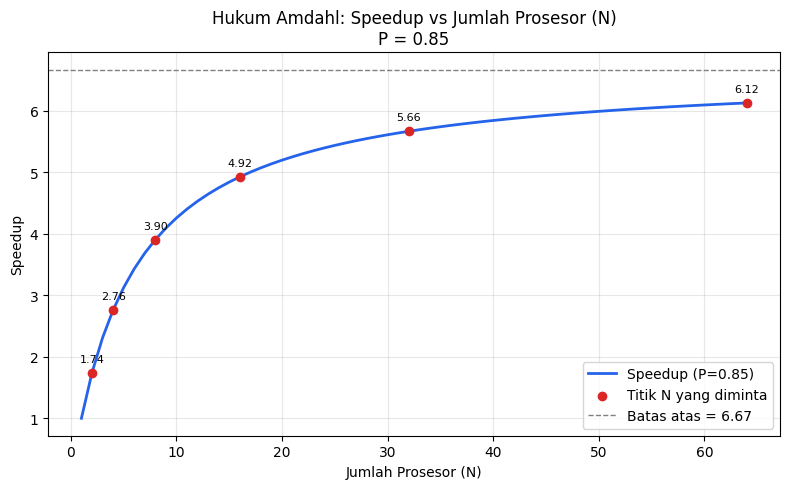

In [7]:
import matplotlib.pyplot as plt
import numpy as np

N_kontinu = np.arange(1, 65)
speedup_kontinu = [amdahl_speedup(P, n) for n in N_kontinu]

plt.figure(figsize=(8, 5))
plt.plot(N_kontinu, speedup_kontinu, color="#2563eb", linewidth=2, label=f"Speedup (P={P})")
plt.scatter(daftar_N, [hasil_speedup[n] for n in daftar_N], color="#dc2626", zorder=5, label="Titik N yang diminta")
plt.axhline(batas_atas, color="gray", linestyle="--", linewidth=1, label=f"Batas atas = {batas_atas:.2f}")

for N in daftar_N:
    plt.annotate(f"{hasil_speedup[N]:.2f}", (N, hasil_speedup[N]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.title("Hukum Amdahl: Speedup vs Jumlah Prosesor (N)\nP = 0.85")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("amdahl_speedup.png", dpi=120)
plt.show()

### c) Pada N berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil ("diminishing returns")?

In [8]:
print(f"{'N':>4} | {'Speedup':>10} | {'Kenaikan dari N sebelumnya':>28} | {'% dari batas atas':>18}")
print("-" * 70)
prev = None
for N in daftar_N:
    s = hasil_speedup[N]
    kenaikan = s - prev if prev is not None else float("nan")
    persen_batas = s / batas_atas * 100
    kenaikan_str = f"{kenaikan:.4f}" if prev is not None else "-"
    print(f"{N:>4} | {s:>10.4f} | {kenaikan_str:>28} | {persen_batas:>17.2f}%")
    prev = s

   N |    Speedup |   Kenaikan dari N sebelumnya |  % dari batas atas
----------------------------------------------------------------------
   2 |     1.7391 |                            - |             26.09%
   4 |     2.7586 |                       1.0195 |             41.38%
   8 |     3.9024 |                       1.1438 |             58.54%
  16 |     4.9231 |                       1.0206 |             73.85%
  32 |     5.6637 |                       0.7406 |             84.96%
  64 |     6.1244 |                       0.4607 |             91.87%


**Jawaban:** Dari tabel dan grafik terlihat bahwa kenaikan speedup mulai sangat kecil mulai sekitar **N = 16 ke atas**:

- Dari N=2 → N=4, speedup naik cukup besar (≈ +1.02).
- Dari N=8 → N=16, kenaikan mulai mengecil (≈ +1.02 → sudah mendekati 74% dari batas atas).
- Dari **N=16 → N=32**, kenaikan hanya **≈ +0.74**, dan dari **N=32 → N=64** kenaikan hanya **≈ +0.46**, padahal jumlah prosesor sudah dilipatgandakan.
- Pada N=64, speedup sudah mencapai **≈ 91.9%** dari batas atas teoritis (1/(1-P) = 6.667), yang berarti menambah prosesor lebih banyak lagi hanya akan memberi tambahan sangat kecil mendekati batas tersebut.

**Alasan:** Ini adalah konsekuensi langsung dari Hukum Amdahl — karena 15% dari program **tidak dapat diparalelkan** (bagian sekuensial), bagian ini menjadi *bottleneck* yang membatasi speedup maksimum sebesar $1/(1-P) = 6.67$, berapa pun banyaknya prosesor yang ditambahkan. Setelah N cukup besar (di sini sekitar N ≥ 16–32), kontribusi bagian paralel ($P/N$) terhadap total waktu sudah sangat kecil dibanding bagian sekuensial yang tetap, sehingga menambah prosesor lagi tidak banyak membantu — inilah fenomena *diminishing returns*.

## 3. Benchmark Mandiri

Fungsi CPU-bound yang digunakan: **`hitung_prima(n)`** — menghitung semua bilangan prima hingga `n` menggunakan pendekatan sederhana (trial division). Fungsi ini murni CPU-bound karena hanya melakukan komputasi aritmatika berulang tanpa I/O.

Waktu eksekusi diukur untuk 4 ukuran input berbeda menggunakan dua cara:
1. `time.perf_counter()` — mengukur satu kali eksekusi secara manual.
2. `timeit` — menjalankan fungsi berulang kali dan mengambil rata-rata/terbaik untuk hasil yang lebih stabil.

In [9]:
def hitung_prima(n):
    """
    Menghitung daftar semua bilangan prima <= n menggunakan trial division.
    Fungsi CPU-bound sederhana (tanpa I/O) untuk keperluan benchmarking.
    """
    if n < 2:
        return []
    daftar_prima = []
    for angka in range(2, n + 1):
        is_prima = True
        akar = int(angka ** 0.5) + 1
        for pembagi in range(2, akar):
            if angka % pembagi == 0:
                is_prima = False
                break
        if is_prima:
            daftar_prima.append(angka)
    return daftar_prima

# Uji cepat
print("Jumlah bilangan prima <= 100:", len(hitung_prima(100)))
print("5 bilangan prima terakhir <= 100:", hitung_prima(100)[-5:])

Jumlah bilangan prima <= 100: 25
5 bilangan prima terakhir <= 100: [73, 79, 83, 89, 97]


In [10]:
import time
import timeit

ukuran_input = [5_000, 10_000, 20_000, 40_000]

hasil_perf_counter = []
for n in ukuran_input:
    t_mulai = time.perf_counter()
    hasil_prima = hitung_prima(n)
    t_selesai = time.perf_counter()
    waktu = t_selesai - t_mulai
    hasil_perf_counter.append(waktu)
    print(f"n={n:>7} | perf_counter: {waktu:.4f} s | jumlah prima ditemukan: {len(hasil_prima)}")

n=   5000 | perf_counter: 0.0022 s | jumlah prima ditemukan: 669
n=  10000 | perf_counter: 0.0044 s | jumlah prima ditemukan: 1229
n=  20000 | perf_counter: 0.0100 s | jumlah prima ditemukan: 2262
n=  40000 | perf_counter: 0.0237 s | jumlah prima ditemukan: 4203


In [11]:
hasil_timeit = []
for n in ukuran_input:
    # timeit.timeit menjalankan fungsi 'number' kali dan mengembalikan total waktu.
    # Kita gunakan number=3 (kompromi antara akurasi dan waktu tunggu), lalu ambil rata-rata per eksekusi.
    waktu_total = timeit.timeit(lambda: hitung_prima(n), number=3)
    waktu_rata2 = waktu_total / 3
    hasil_timeit.append(waktu_rata2)
    print(f"n={n:>7} | timeit (rata-rata dari 3x): {waktu_rata2:.4f} s")

n=   5000 | timeit (rata-rata dari 3x): 0.0021 s
n=  10000 | timeit (rata-rata dari 3x): 0.0043 s
n=  20000 | timeit (rata-rata dari 3x): 0.0100 s
n=  40000 | timeit (rata-rata dari 3x): 0.0236 s


### Tabel & Plot Perbandingan `time.perf_counter()` vs `timeit`

In [12]:
print(f"{'n':>8} | {'perf_counter (s)':>18} | {'timeit rata-rata (s)':>22} | {'selisih (s)':>12}")
print("-" * 68)
for n, tp, tt in zip(ukuran_input, hasil_perf_counter, hasil_timeit):
    print(f"{n:>8} | {tp:>18.4f} | {tt:>22.4f} | {abs(tp - tt):>12.4f}")

       n |   perf_counter (s) |   timeit rata-rata (s) |  selisih (s)
--------------------------------------------------------------------
    5000 |             0.0022 |                 0.0021 |       0.0000
   10000 |             0.0044 |                 0.0043 |       0.0001
   20000 |             0.0100 |                 0.0100 |       0.0001
   40000 |             0.0237 |                 0.0236 |       0.0001


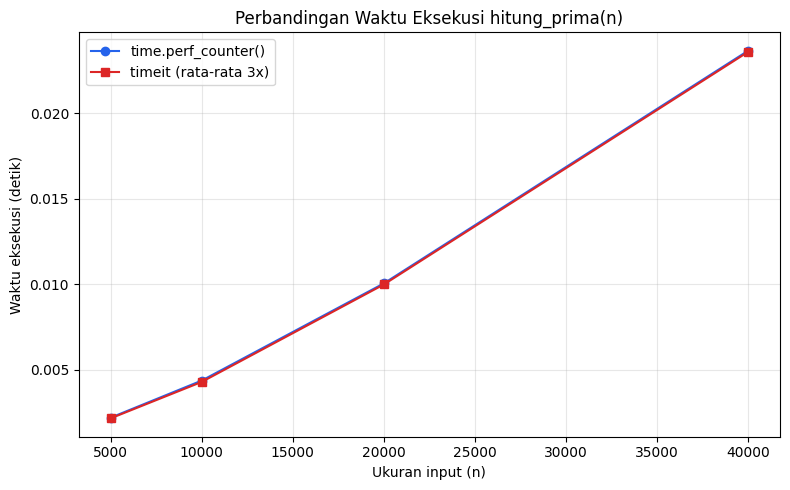

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(ukuran_input, hasil_perf_counter, marker="o", color="#2563eb", label="time.perf_counter()")
plt.plot(ukuran_input, hasil_timeit, marker="s", color="#dc2626", label="timeit (rata-rata 3x)")
plt.title("Perbandingan Waktu Eksekusi hitung_prima(n)")
plt.xlabel("Ukuran input (n)")
plt.ylabel("Waktu eksekusi (detik)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_hitung_prima.png", dpi=120)
plt.show()

**Penjelasan hasil:**

- Waktu eksekusi `hitung_prima(n)` meningkat secara **non-linear** seiring bertambahnya `n`, sesuai dengan kompleksitas algoritma trial division yang mendekati $O(n \sqrt{n})$.
- Hasil dari `time.perf_counter()` dan `timeit` secara umum **konsisten** (menunjukkan tren kenaikan yang sama), namun `timeit` cenderung memberikan hasil yang **lebih stabil** karena menjalankan fungsi beberapa kali dan tidak terlalu terpengaruh oleh gangguan sesaat dari sistem operasi (seperti proses latar belakang), sedangkan `time.perf_counter()` hanya mengukur satu kali eksekusi sehingga lebih rentan terhadap noise.
- Untuk pengukuran benchmark yang lebih andal, `timeit` umumnya lebih direkomendasikan, sedangkan `perf_counter()` lebih praktis untuk mengukur durasi sekali jalan dalam aplikasi nyata.

## 4. Refleksi Singkat (maks. 150 kata)

Hukum Amdahl lebih relevan digunakan ketika **ukuran masalah (problem size) tetap/tidak berubah**, dan kita hanya ingin mempercepat penyelesaian tugas yang sama dengan menambah jumlah prosesor, cocok untuk kasus *fixed-size speedup*. Contoh nyata: mempercepat rendering satu video berdurasi tetap dengan menambah jumlah core, di mana bagian sekuensial (seperti encoding header/metadata) membatasi speedup maksimum.

Sebaliknya, Hukum Gustafson lebih relevan ketika **ukuran masalah bertambah seiring bertambahnya jumlah prosesor**, karena tujuannya bukan mempercepat tugas yang sama, melainkan mengerjakan tugas yang lebih besar dalam waktu yang sama, cocok untuk *scaled speedup*. Contoh nyata: prediksi cuaca skala besar, di mana ketika tersedia lebih banyak prosesor, resolusi simulasi (jumlah wilayah/grid) ditingkatkan agar hasil semakin detail, bukan sekadar mempercepat simulasi dengan resolusi yang sama.

Singkatnya: Amdahl untuk *mempercepat* masalah tetap, Gustafson untuk *memperbesar* masalah dalam waktu tetap.

